### Step 1 — Mount + imports + paths

In [1]:
from google.colab import drive
drive.mount('/content/drive')

from pathlib import Path
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
from torch.utils.data import Dataset

BASE_DIR = Path("/content/drive/MyDrive/rectified_flow_ct2dose")
SPLIT_DIR = BASE_DIR / "data" / "splits"
CKPT_DIR = BASE_DIR / "outputs" / "checkpoints"
OUT_DIR = BASE_DIR / "analysis" / "ct2dose_phase4_targeted_evaluation"
OUT_DIR.mkdir(parents=True, exist_ok=True)

VAL_MANIFEST = SPLIT_DIR / "train_pairs_3d_val_phase3_500.json"

TUNED_CKPT = CKPT_DIR / "lr5e4_base24_bs2_cont_to_50_best.pt"
MIXED_T010_CKPT = CKPT_DIR / "phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_best.pt"
MIXED_T015_CKPT = CKPT_DIR / "ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt"

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("device:", device)

print("VAL_MANIFEST exists:", VAL_MANIFEST.exists())
print("TUNED_CKPT exists:", TUNED_CKPT.exists())
print("MIXED_T010_CKPT exists:", MIXED_T010_CKPT.exists())
print("MIXED_T015_CKPT exists:", MIXED_T015_CKPT.exists())

Mounted at /content/drive
device: cuda
VAL_MANIFEST exists: True
TUNED_CKPT exists: True
MIXED_T010_CKPT exists: True
MIXED_T015_CKPT exists: True


### Step 2 — Optional title

In [2]:
from IPython.display import Markdown, display

display(Markdown(r"""
# CT-to-Dose Phase 4: Targeted Evaluation
## Models
- tuned baseline
- mixed T=0.10, alpha=0.30, mw=3.0
- mixed T=0.15, alpha=0.30, mw=3.0
"""))


# CT-to-Dose Phase 4: Targeted Evaluation
## Models
- tuned baseline
- mixed T=0.10, alpha=0.30, mw=3.0
- mixed T=0.15, alpha=0.30, mw=3.0


### Step 3 — Dataset + model definitions

In [2]:
DOSE_SCALE = 1000.0
EPS = 1e-8

def normalize_ct(x):
    x = np.clip(x, -1024.0, 1500.0)
    x = (x + 1024.0) / (1500.0 + 1024.0)
    return x.astype(np.float32)

def denormalize_ct(x_norm):
    return x_norm * (1500.0 + 1024.0) - 1024.0

class CubePair3DDataset(Dataset):
    def __init__(self, manifest_path, dose_scale=1000.0):
        with open(manifest_path, "r", encoding="utf-8") as f:
            self.records = json.load(f)
        self.dose_scale = dose_scale

    def __len__(self):
        return len(self.records)

    def __getitem__(self, idx):
        rec = self.records[idx]

        x0 = np.load(rec["input_path"]).astype(np.float32)
        x1 = np.load(rec["output_path"]).astype(np.float32)

        x0 = normalize_ct(x0)
        x1 = (x1 * self.dose_scale).astype(np.float32)

        x0 = torch.from_numpy(x0).unsqueeze(0)
        x1 = torch.from_numpy(x1).unsqueeze(0)
        return x0, x1


class DoubleConv3D(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv3d(in_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
            nn.Conv3d(out_ch, out_ch, kernel_size=3, padding=1),
            nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.block(x)


class ConditionalUNetFlow3D(nn.Module):
    def __init__(self, in_ch=3, out_ch=1, base_ch=24):
        super().__init__()

        self.enc1 = DoubleConv3D(in_ch, base_ch)
        self.pool1 = nn.MaxPool3d(2)

        self.enc2 = DoubleConv3D(base_ch, base_ch * 2)
        self.pool2 = nn.MaxPool3d(2)

        self.bottleneck = DoubleConv3D(base_ch * 2, base_ch * 4)

        self.up2 = nn.ConvTranspose3d(base_ch * 4, base_ch * 2, kernel_size=2, stride=2)
        self.dec2 = DoubleConv3D(base_ch * 4, base_ch * 2)

        self.up1 = nn.ConvTranspose3d(base_ch * 2, base_ch, kernel_size=2, stride=2)
        self.dec1 = DoubleConv3D(base_ch * 2, base_ch)

        self.out_conv = nn.Conv3d(base_ch, out_ch, kernel_size=1)

    def forward(self, xt, x0, t):
        t_map = t.expand(-1, 1, xt.shape[2], xt.shape[3], xt.shape[4])
        inp = torch.cat([xt, x0, t_map], dim=1)

        e1 = self.enc1(inp)
        e2 = self.enc2(self.pool1(e1))
        b = self.bottleneck(self.pool2(e2))

        d2 = self.up2(b)
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2)

        d1 = self.up1(d2)
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1)

        return self.out_conv(d1)


@torch.no_grad()
def euler_sample_flow_3d(model, x0, n_steps=30):
    model.eval()
    z = x0.clone()
    dt = 1.0 / n_steps

    for k in range(n_steps):
        t = torch.full((z.shape[0], 1, 1, 1, 1), k / n_steps, device=z.device)
        v = model(z, x0, t)
        z = z + dt * v

    return z

### Step 4 — Prediction helpers

In [3]:
@torch.no_grad()
def get_flow_prediction(model, dataset, idx, device, n_steps=30):
    x0, x1 = dataset[idx]
    x0_t = x0.unsqueeze(0).to(device)
    pred = euler_sample_flow_3d(model, x0_t, n_steps=n_steps).cpu().squeeze().numpy()

    ct_vol = x0.squeeze().numpy()       # normalized CT
    gt_vol = x1.squeeze().numpy()       # scaled dose
    return ct_vol, gt_vol, pred


def find_best_dose_slice_index(volume):
    slice_sums = volume.reshape(volume.shape[0], -1).sum(axis=1)
    return int(np.argmax(slice_sums))


def find_peak_xy(volume, slice_idx):
    slice_2d = volume[slice_idx]
    return np.unravel_index(np.argmax(slice_2d), slice_2d.shape)

### Step 5 — Profile percentage-error helpers

In [4]:
def compute_profile_percentage_error(
    gt_curve,
    pred_curve,
    mode="relative_to_curve_max",
    threshold=0.01,
    eps=1e-8,
    return_mask=False
):
    gt_curve = np.asarray(gt_curve, dtype=np.float64)
    pred_curve = np.asarray(pred_curve, dtype=np.float64)

    if mode == "relative_to_curve_max":
        ref = float(np.max(gt_curve))
        relevant_threshold = max(threshold * ref, eps)
    elif mode == "absolute":
        relevant_threshold = max(float(threshold), eps)
    else:
        raise ValueError(f"Unknown mode: {mode}")

    valid_mask = gt_curve >= relevant_threshold
    pct_err = np.full_like(gt_curve, np.nan, dtype=np.float64)
    pct_err[valid_mask] = (
        100.0 * np.abs(pred_curve[valid_mask] - gt_curve[valid_mask]) /
        np.maximum(gt_curve[valid_mask], eps)
    )

    if return_mask:
        return pct_err, valid_mask, relevant_threshold
    return pct_err


def summarize_profile_percentage_error(
    gt_profile,
    pred_profile,
    mode="relative_to_curve_max",
    threshold=0.01,
    eps=1e-8
):
    pct_error, mask, relevant_threshold = compute_profile_percentage_error(
        gt_profile, pred_profile, mode=mode, threshold=threshold, eps=eps, return_mask=True
    )

    if np.any(mask):
        mean_pct = float(np.nanmean(pct_error))
        max_pct = float(np.nanmax(pct_error))
        valid_count = int(np.sum(mask))
        total_count = int(len(mask))
    else:
        mean_pct = np.nan
        max_pct = np.nan
        valid_count = 0
        total_count = int(len(mask))

    return {
        "mean_pct_error": mean_pct,
        "max_pct_error": max_pct,
        "pct_error_curve": pct_error,
        "mask": mask,
        "valid_count": valid_count,
        "total_count": total_count,
        "relevant_threshold": relevant_threshold,
    }

### Step 6 — Plot helpers

In [5]:
def save_cross_section_with_matched_scales(
    ct_vol, gt_vol, pred_vol, slice_idx, save_path, title_prefix=""
):
    ct_slice = ct_vol[slice_idx]
    gt_slice = gt_vol[slice_idx]
    pred_slice = pred_vol[slice_idx]
    abs_diff = np.abs(pred_slice - gt_slice)

    fig, axes = plt.subplots(1, 4, figsize=(16, 4))

    axes[0].imshow(ct_slice, cmap="gray")
    axes[0].set_title(f"{title_prefix} Input CT")
    axes[0].axis("off")

    im1 = axes[1].imshow(gt_slice, cmap="hot")
    axes[1].set_title(f"{title_prefix} Ground Truth")
    axes[1].axis("off")
    plt.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04)

    im2 = axes[2].imshow(pred_slice, cmap="hot", vmin=gt_slice.min(), vmax=gt_slice.max())
    axes[2].set_title(f"{title_prefix} Prediction")
    axes[2].axis("off")
    plt.colorbar(im2, ax=axes[2], fraction=0.046, pad=0.04)

    im3 = axes[3].imshow(abs_diff, cmap="hot")
    axes[3].set_title(f"{title_prefix} Abs Difference")
    axes[3].axis("off")
    plt.colorbar(im3, ax=axes[3], fraction=0.046, pad=0.04)

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()


def plot_profile_with_percentage_error(
    gt_curve,
    pred_curve,
    title,
    xlabel,
    save_path,
    pct_mode="relative_to_curve_max",
    pct_threshold=0.01,
    eps=1e-8,
    tail_start_idx=None,
    invalid_shading=True
):
    """
    改进版：
    1. 上半部分保留全局曲线
    2. 中间增加 tail zoom，避免“后面看起来像 0”
    3. 下半部分明确说明：percentage error only computed in relevant region
    4. 对 excluded low-dose tail 加灰色阴影，避免误解为 error=0
    """

    gt_curve = np.asarray(gt_curve, dtype=np.float64)
    pred_curve = np.asarray(pred_curve, dtype=np.float64)
    abs_diff = np.abs(gt_curve - pred_curve)
    x = np.arange(len(gt_curve))

    pct_summary = summarize_profile_percentage_error(
        gt_curve,
        pred_curve,
        mode=pct_mode,
        threshold=pct_threshold,
        eps=eps
    )

    pct_curve = pct_summary["pct_error_curve"]
    mean_pct = pct_summary["mean_pct_error"]
    max_pct = pct_summary["max_pct_error"]
    valid_count = pct_summary["valid_count"]
    total_count = pct_summary["total_count"]
    relevant_threshold = pct_summary["relevant_threshold"]
    valid_mask = pct_summary["mask"]

    # -------- 确定 invalid / tail 区域 --------
    invalid_idx = np.where(~valid_mask)[0]

    if tail_start_idx is None:
        if len(invalid_idx) > 0:
            tail_start_idx = int(invalid_idx[0])
        else:
            tail_start_idx = max(0, len(gt_curve) // 2)

    tail_start_idx = max(0, min(tail_start_idx, len(gt_curve) - 1))

    # tail 区域的 y 轴范围
    tail_max = float(np.max([
        np.max(gt_curve[tail_start_idx:]),
        np.max(pred_curve[tail_start_idx:]),
        np.max(abs_diff[tail_start_idx:])
    ]))
    tail_max = max(tail_max, 1e-6)
    tail_ylim = 1.15 * tail_max

    # percentage error y 上限
    if valid_count > 0 and np.isfinite(max_pct):
        pct_ylim = 1.15 * max(max_pct, 1.0)
    else:
        pct_ylim = 1.0

    # -------- 画图 --------
    fig, axes = plt.subplots(
        3, 1,
        figsize=(8, 11),
        gridspec_kw={"height_ratios": [2.0, 1.4, 1.5]}
    )

    # ======================
    # Panel 1: full profile
    # ======================
    axes[0].plot(x, gt_curve, label="Ground Truth", linewidth=2)
    axes[0].plot(x, pred_curve, label="Prediction", linewidth=2)
    axes[0].plot(x, abs_diff, label="Abs Difference", linewidth=2)

    if invalid_shading and len(invalid_idx) > 0:
        axes[0].axvspan(
            tail_start_idx, len(gt_curve) - 1,
            color="gray", alpha=0.12,
            label="Excluded low-dose tail"
        )

    axes[0].axvline(
        tail_start_idx, linestyle="--", linewidth=1.5,
        color="black"
    )

    axes[0].set_title(title)
    axes[0].set_ylabel("Dose")
    axes[0].grid(True)
    axes[0].legend()

    # ======================
    # Panel 2: tail zoom
    # ======================
    axes[1].plot(x, gt_curve, label="Ground Truth", linewidth=2)
    axes[1].plot(x, pred_curve, label="Prediction", linewidth=2)
    axes[1].plot(x, abs_diff, label="Abs Difference", linewidth=2)

    if invalid_shading and len(invalid_idx) > 0:
        axes[1].axvspan(
            tail_start_idx, len(gt_curve) - 1,
            color="gray", alpha=0.12
        )

    axes[1].set_xlim(tail_start_idx, len(gt_curve) - 1)
    axes[1].set_ylim(0, tail_ylim)
    axes[1].set_title(
        f"Tail zoom (from index {tail_start_idx})"
    )
    axes[1].set_ylabel("Dose")
    axes[1].grid(True)
    axes[1].legend()

    # ======================
    # Panel 3: percentage error
    # ======================
    axes[2].plot(x, pct_curve, label="Percentage Error (%)", linewidth=2)

    if invalid_shading and len(invalid_idx) > 0:
        axes[2].axvspan(
            tail_start_idx, len(gt_curve) - 1,
            color="gray", alpha=0.12,
            label="Excluded low-dose tail"
        )

    axes[2].set_ylim(0, pct_ylim)
    axes[2].set_xlabel(xlabel)
    axes[2].set_ylabel("Percentage Error (%)")
    axes[2].grid(True)

    if valid_count > 0:
        axes[2].set_title(
            f"Percentage error only for gt >= {relevant_threshold:.5f} "
            f"(valid {valid_count}/{total_count})\n"
            f"Mean % error = {mean_pct:.3f}, Max % error = {max_pct:.3f}"
        )
    else:
        axes[2].set_title(
            "Percentage error: no valid region above threshold"
        )

    axes[2].legend()

    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches="tight")
    plt.close()

    return {
        "mean_pct_error": mean_pct,
        "max_pct_error": max_pct,
        "valid_count": valid_count,
        "total_count": total_count,
        "relevant_threshold": relevant_threshold,
        "tail_start_idx": tail_start_idx,
    }

### Step 7 — Representative-case analyzer

In [6]:
def analyze_one_case(dataset, sample_idx, model, device, out_dir, prefix):
    ct_vol, gt_vol, pred_vol = get_flow_prediction(model, dataset, sample_idx, device, n_steps=30)

    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    save_cross_section_with_matched_scales(
        ct_vol, gt_vol, pred_vol, slice_idx,
        out_dir / f"{prefix}_cross_section.png",
        title_prefix=prefix.replace("_", " ").title()
    )

    gt_along = gt_vol[slice_idx, peak_y, :]
    pred_along = pred_vol[slice_idx, peak_y, :]
    along_stats = plot_profile_with_percentage_error(
        gt_along,
        pred_along,
        f"{prefix.replace('_', ' ').title()}: Along-Beam Profile",
        "x index (approx. beam direction)",
        out_dir / f"{prefix}_along_beam_profile_with_pct_error.png",
        pct_mode="relative_to_curve_max",
        pct_threshold=0.01,
        tail_start_idx=max(0, len(gt_along) // 2),
        invalid_shading=True
    )

    gt_perp = gt_vol[slice_idx, :, peak_x]
    pred_perp = pred_vol[slice_idx, :, peak_x]
    perp_stats = plot_profile_with_percentage_error(
        gt_perp,
        pred_perp,
        f"{prefix.replace('_', ' ').title()}: Perpendicular Profile",
        "y index (perpendicular to beam)",
        out_dir / f"{prefix}_perpendicular_profile_with_pct_error.png",
        pct_mode="relative_to_curve_max",
        pct_threshold=0.01,
        tail_start_idx=max(0, len(gt_perp) // 2),
        invalid_shading=True
    )

    mse = float(np.mean((pred_vol - gt_vol) ** 2))
    mae = float(np.mean(np.abs(pred_vol - gt_vol)))
    rel_err_pct = float(100.0 * np.sum(np.abs(pred_vol - gt_vol)) / (np.sum(np.abs(gt_vol)) + EPS))

    return {
        "sample_idx": sample_idx,
        "best_slice": slice_idx,
        "peak_y": peak_y,
        "peak_x": peak_x,
        "gt_max": float(gt_vol.max()),
        "mse": mse,
        "mae": mae,
        "relative_error_pct": rel_err_pct,

        "along_mean_pct_error": along_stats["mean_pct_error"],
        "along_max_pct_error": along_stats["max_pct_error"],
        "along_valid_count": along_stats["valid_count"],
        "along_total_count": along_stats["total_count"],
        "along_relevant_threshold": along_stats["relevant_threshold"],

        "perp_mean_pct_error": perp_stats["mean_pct_error"],
        "perp_max_pct_error": perp_stats["max_pct_error"],
        "perp_valid_count": perp_stats["valid_count"],
        "perp_total_count": perp_stats["total_count"],
        "perp_relevant_threshold": perp_stats["relevant_threshold"],
    }

### Step 8 — Unified evaluation config

In [8]:
EVAL_THRESHOLD = 0.10
EVAL_THRESHOLD_MODE = "absolute"

print("Unified evaluation threshold:", EVAL_THRESHOLD)

Unified evaluation threshold: 0.1


### Step 9 — Targeted evaluation metrics

In [9]:
def get_case_threshold(gt_vol, threshold=0.10, mode="absolute"):
    if mode == "absolute":
        T = float(threshold)
    elif mode == "relative_to_case_max":
        T = float(threshold) * float(gt_vol.max())
    else:
        raise ValueError(f"Unknown mode: {mode}")
    return max(T, 1e-8)


def compute_targeted_eval_metrics(gt_vol, pred_vol, threshold=0.10, mode="absolute"):
    T = get_case_threshold(gt_vol, threshold=threshold, mode=mode)

    abs_err = np.abs(pred_vol - gt_vol)
    sq_err = (pred_vol - gt_vol) ** 2

    weight = np.maximum(T, gt_vol) / T
    weighted_mse = float(np.mean(weight * sq_err))

    high_mask = gt_vol >= T
    outside_mask = gt_vol < T

    gt_max = float(gt_vol.max())
    peak_core_mask = gt_vol >= (0.8 * gt_max)
    peak_shoulder_mask = (gt_vol >= 0.3 * gt_max) & (gt_vol < 0.8 * gt_max)

    def safe_mean(arr):
        return float(np.mean(arr)) if arr.size > 0 else np.nan

    def safe_max(arr):
        return float(np.max(arr)) if arr.size > 0 else np.nan

    def safe_p95(arr):
        return float(np.percentile(arr, 95)) if arr.size > 0 else np.nan

    def safe_rel_err(gt_arr, pred_arr):
        denom = np.sum(np.abs(gt_arr))
        if gt_arr.size == 0 or denom <= 1e-8:
            return np.nan
        return float(100.0 * np.sum(np.abs(pred_arr - gt_arr)) / denom)

    return {
        "overall_mse": float(np.mean(sq_err)),
        "overall_mae": float(np.mean(abs_err)),

        "weighted_mse": weighted_mse,

        "high_mse": safe_mean(sq_err[high_mask]),
        "high_mae": safe_mean(abs_err[high_mask]),
        "high_rel_err_pct": safe_rel_err(gt_vol[high_mask], pred_vol[high_mask]),

        "outside_mse": safe_mean(sq_err[outside_mask]),
        "outside_mae": safe_mean(abs_err[outside_mask]),
        "outside_max_abs_error": safe_max(abs_err[outside_mask]),
        "outside_p95_abs_error": safe_p95(abs_err[outside_mask]),

        "peak_core_mae": safe_mean(abs_err[peak_core_mask]),
        "peak_shoulder_mae": safe_mean(abs_err[peak_shoulder_mask]),

        "threshold_used": T,
        "num_high_voxels": int(high_mask.sum()),
        "num_outside_voxels": int(outside_mask.sum()),
    }

### Step 10 — Heuristic bone-in-beam detector

In [10]:
def compute_bone_in_beam_heuristic(
    ct_vol_norm,
    gt_vol,
    threshold=0.10,
    band_halfwidth=1,
    bone_hu_threshold=300.0,
    min_bone_fraction=0.05
):
    """
    Heuristic:
    1. Find the best dose slice.
    2. Use a narrow band around the beam center row (peak_y).
    3. Restrict to x-locations where dose is relevant (gt >= threshold).
    4. Convert normalized CT back to approximate HU.
    5. Mark as bone-in-beam candidate if a sufficient fraction exceeds HU threshold.
    """
    slice_idx = find_best_dose_slice_index(gt_vol)
    peak_y, peak_x = find_peak_xy(gt_vol, slice_idx)

    gt_slice = gt_vol[slice_idx]
    ct_slice_hu = denormalize_ct(ct_vol_norm[slice_idx])

    y0 = max(0, peak_y - band_halfwidth)
    y1 = min(gt_slice.shape[0], peak_y + band_halfwidth + 1)

    dose_band = gt_slice[y0:y1, :]
    ct_band_hu = ct_slice_hu[y0:y1, :]

    relevant_mask = dose_band >= threshold

    if relevant_mask.sum() == 0:
        return {
            "bone_in_beam_candidate": False,
            "bone_fraction_in_relevant_band": 0.0,
            "max_hu_in_relevant_band": float(np.max(ct_band_hu)),
            "beam_slice_idx": slice_idx,
            "beam_peak_y": int(peak_y),
            "beam_peak_x": int(peak_x),
        }

    bone_mask = (ct_band_hu >= bone_hu_threshold) & relevant_mask
    bone_fraction = float(bone_mask.sum() / relevant_mask.sum())
    max_hu = float(np.max(ct_band_hu[relevant_mask]))

    return {
        "bone_in_beam_candidate": bone_fraction >= min_bone_fraction,
        "bone_fraction_in_relevant_band": bone_fraction,
        "max_hu_in_relevant_band": max_hu,
        "beam_slice_idx": int(slice_idx),
        "beam_peak_y": int(peak_y),
        "beam_peak_x": int(peak_x),
    }

### Step 11 — Load dataset and all models

In [11]:
val_dataset_3d = CubePair3DDataset(VAL_MANIFEST, dose_scale=DOSE_SCALE)

model_specs = {
    "tuned": TUNED_CKPT,
    "mixed_T010_a030_mw3": MIXED_T010_CKPT,
    "mixed_T015_a030_mw3": MIXED_T015_CKPT,
}

models = {}

for model_name, ckpt_path in model_specs.items():
    ckpt = torch.load(ckpt_path, map_location="cpu")
    model = ConditionalUNetFlow3D(in_ch=3, out_ch=1, base_ch=24).to(device)
    model.load_state_dict(ckpt["model_state_dict"])
    model.eval()
    models[model_name] = model
    print("Loaded:", model_name, "from", ckpt_path)

print("Validation samples:", len(val_dataset_3d))

Loaded: tuned from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/lr5e4_base24_bs2_cont_to_50_best.pt
Loaded: mixed_T010_a030_mw3 from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p10_a0p30_mw3_best.pt
Loaded: mixed_T015_a030_mw3 from /content/drive/MyDrive/rectified_flow_ct2dose/outputs/checkpoints/ct2dose_phase4_mixed_weighted_flow_lr5e4_base24_bs2_T0p15_a0p30_mw3_best.pt
Validation samples: 500


### Step 12 — Full casewise targeted evaluation

In [12]:
all_rows = []

for idx in range(len(val_dataset_3d)):
    # tuned model used just to get ct and gt once
    ct_vol, gt_vol, _ = get_flow_prediction(models["tuned"], val_dataset_3d, idx, device, n_steps=30)

    bone_info = compute_bone_in_beam_heuristic(
        ct_vol_norm=ct_vol,
        gt_vol=gt_vol,
        threshold=EVAL_THRESHOLD,
        band_halfwidth=1,
        bone_hu_threshold=300.0,
        min_bone_fraction=0.05
    )

    for model_name, model in models.items():
        _, _, pred_vol = get_flow_prediction(model, val_dataset_3d, idx, device, n_steps=30)

        metrics = compute_targeted_eval_metrics(
            gt_vol, pred_vol,
            threshold=EVAL_THRESHOLD,
            mode=EVAL_THRESHOLD_MODE
        )

        row = {
            "model": model_name,
            "sample_idx": idx,
            **bone_info,
            **metrics
        }
        all_rows.append(row)

comparison_df = pd.DataFrame(all_rows)

comparison_csv = OUT_DIR / f"ct2dose_targeted_casewise_metrics_evalT{str(EVAL_THRESHOLD).replace('.', 'p')}.csv"
comparison_df.to_csv(comparison_csv, index=False)

print("Saved:", comparison_csv)
display(comparison_df.head())

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/ct2dose_targeted_casewise_metrics_evalT0p1.csv


,model,sample_idx,bone_in_beam_candidate,bone_fraction_in_relevant_band,max_hu_in_relevant_band,beam_slice_idx,beam_peak_y,beam_peak_x,overall_mse,overall_mae,...,high_rel_err_pct,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae,threshold_used,num_high_voxels,num_outside_voxels
0,tuned,0,True,0.184211,830.923096,16,16,0,0.000015,0.002473,...,2.674173,0.000009,0.002039,0.033033,0.005827,0.116184,0.040654,0.1,4792,27976
1,mixed_T010_a030_mw3,0,True,0.184211,830.923096,16,16,0,0.000017,0.002729,...,3.067758,0.000010,0.002213,0.030378,0.006510,0.016533,0.026898,0.1,4792,27976
2,mixed_T015_a030_mw3,0,True,0.184211,830.923096,16,16,0,0.000023,0.003124,...,4.279956,0.000010,0.002287,0.029699,0.006290,0.134365,0.034779,0.1,4792,27976
3,tuned,1,False,0.000000,48.529053,16,16,0,0.000024,0.002947,...,2.663383,0.000019,0.002665,0.048242,0.009109,0.119688,0.050971,0.1,4218,28550
4,mixed_T010_a030_mw3,1,False,0.000000,48.529053,16,16,0,0.000028,0.003210,...,2.468965,0.000024,0.003019,0.050761,0.010374,0.032907,0.030689,0.1,4218,28550


### Step 13 — Summary table

In [13]:
summary_df = comparison_df.groupby("model").agg({
    "overall_mse": "mean",
    "overall_mae": "mean",
    "weighted_mse": "mean",
    "high_mse": "mean",
    "high_mae": "mean",
    "high_rel_err_pct": "mean",
    "outside_mse": "mean",
    "outside_mae": "mean",
    "outside_max_abs_error": "mean",
    "outside_p95_abs_error": "mean",
    "peak_core_mae": "mean",
    "peak_shoulder_mae": "mean",
}).reset_index()

summary_csv = OUT_DIR / f"ct2dose_targeted_summary_evalT{str(EVAL_THRESHOLD).replace('.', 'p')}.csv"
summary_df.to_csv(summary_csv, index=False)

print("Saved:", summary_csv)
display(summary_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/ct2dose_targeted_summary_evalT0p1.csv


,model,overall_mse,overall_mae,weighted_mse,high_mse,high_mae,high_rel_err_pct,outside_mse,outside_mae,outside_max_abs_error,outside_p95_abs_error,peak_core_mae,peak_shoulder_mae
0,mixed_T010_a030_mw3,0.000018,0.002735,0.000036,0.000051,0.004753,2.769943,0.000014,0.002484,0.034395,0.007353,0.050831,0.020989
1,mixed_T015_a030_mw3,0.000018,0.002737,0.000036,0.000052,0.004922,2.843976,0.000013,0.002441,0.035028,0.007104,0.047260,0.019714
2,tuned,0.000017,0.002662,0.000038,0.000052,0.004830,2.802524,0.000013,0.002382,0.032495,0.006932,0.047654,0.022622


### Step 14 — Bone-in-beam subset summary

In [14]:
bone_subset_df = comparison_df[comparison_df["bone_in_beam_candidate"] == True].copy()
nonbone_subset_df = comparison_df[comparison_df["bone_in_beam_candidate"] == False].copy()

def summarize_subset(df, tag):
    if len(df) == 0:
        return pd.DataFrame()

    out = df.groupby("model").agg({
        "overall_mae": "mean",
        "weighted_mse": "mean",
        "high_mae": "mean",
        "outside_mae": "mean",
        "outside_max_abs_error": "mean",
        "peak_core_mae": "mean",
        "peak_shoulder_mae": "mean",
    }).reset_index()
    out["subset"] = tag
    return out

bone_summary_df = summarize_subset(bone_subset_df, "bone_in_beam_candidate")
nonbone_summary_df = summarize_subset(nonbone_subset_df, "non_bone_candidate")

subset_summary_df = pd.concat([bone_summary_df, nonbone_summary_df], axis=0, ignore_index=True)

subset_summary_csv = OUT_DIR / f"ct2dose_bone_subset_summary_evalT{str(EVAL_THRESHOLD).replace('.', 'p')}.csv"
subset_summary_df.to_csv(subset_summary_csv, index=False)

print("Bone-in-beam candidate count:", bone_subset_df["sample_idx"].nunique())
print("Non-bone candidate count:", nonbone_subset_df["sample_idx"].nunique())
print("Saved:", subset_summary_csv)
display(subset_summary_df)

Bone-in-beam candidate count: 144
Non-bone candidate count: 356
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/ct2dose_bone_subset_summary_evalT0p1.csv


,model,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae,subset
0,mixed_T010_a030_mw3,0.002843,0.000043,0.004896,0.002552,0.036110,0.049827,0.022833,bone_in_beam_candidate
1,mixed_T015_a030_mw3,0.002923,0.000046,0.005538,0.002534,0.036168,0.051173,0.023038,bone_in_beam_candidate
2,tuned,0.002786,0.000048,0.005103,0.002453,0.033666,0.050952,0.025849,bone_in_beam_candidate
3,mixed_T010_a030_mw3,0.002692,0.000033,0.004695,0.002457,0.033701,0.051237,0.020243,non_bone_candidate
4,mixed_T015_a030_mw3,0.002661,0.000031,0.004673,0.002403,0.034567,0.045678,0.018369,non_bone_candidate
5,tuned,0.002612,0.000033,0.004719,0.002353,0.032021,0.046321,0.021317,non_bone_candidate


### Step 15 — Representative cases from tuned ranking

In [15]:
tuned_only = comparison_df[comparison_df["model"] == "tuned"].copy()
tuned_only = tuned_only.sort_values("weighted_mse").reset_index(drop=True)

best_case_idx = int(tuned_only.iloc[0]["sample_idx"])
typical_case_idx = int(tuned_only.iloc[len(tuned_only) // 2]["sample_idx"])
worst_case_idx = int(tuned_only.iloc[-1]["sample_idx"])

print("best_case_idx   =", best_case_idx)
print("typical_case_idx=", typical_case_idx)
print("worst_case_idx  =", worst_case_idx)

best_case_idx   = 496
typical_case_idx= 491
worst_case_idx  = 221


### Step 16 — Same-case comparison for all 3 models

In [16]:
COMPARE_DIR = OUT_DIR / f"ct2dose_targeted_same_cases_evalT{str(EVAL_THRESHOLD).replace('.', 'p')}"
COMPARE_DIR.mkdir(parents=True, exist_ok=True)

case_map = {
    "best": best_case_idx,
    "typical": typical_case_idx,
    "worst": worst_case_idx,
}

all_compare_rows = []

for tag, case_idx in case_map.items():
    print(f"\n=== Running {tag} case: sample_idx={case_idx} ===")

    for model_name, model in models.items():
        model_case_dir = COMPARE_DIR / model_name
        model_case_dir.mkdir(parents=True, exist_ok=True)

        result = analyze_one_case(
            dataset=val_dataset_3d,
            sample_idx=case_idx,
            model=model,
            device=device,
            out_dir=model_case_dir,
            prefix=f"{model_name}_{tag}_sample{case_idx}"
        )
        result.update({
            "model": model_name,
            "case_tag": tag,
            "sample_idx": case_idx
        })
        all_compare_rows.append(result)

compare_cases_df = pd.DataFrame(all_compare_rows)

compare_cases_csv = OUT_DIR / f"ct2dose_targeted_same_cases_summary_evalT{str(EVAL_THRESHOLD).replace('.', 'p')}.csv"
compare_cases_df.to_csv(compare_cases_csv, index=False)

print("Saved:", compare_cases_csv)
display(compare_cases_df)


=== Running best case: sample_idx=496 ===

=== Running typical case: sample_idx=491 ===

=== Running worst case: sample_idx=221 ===
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/ct2dose_targeted_same_cases_summary_evalT0p1.csv


,sample_idx,best_slice,peak_y,peak_x,gt_max,mse,mae,relative_error_pct,along_mean_pct_error,along_max_pct_error,along_valid_count,along_total_count,along_relevant_threshold,perp_mean_pct_error,perp_max_pct_error,perp_valid_count,perp_total_count,perp_relevant_threshold,model,case_tag
0,496,16,16,0,1.398719,0.000004,0.001551,3.392290,3.660991,11.969860,31,32,0.013987,1.495709,3.238712,32,32,0.013987,tuned,best
1,496,16,16,0,1.398719,0.000008,0.001963,4.293469,6.607055,30.816198,31,32,0.013987,3.847758,8.758677,32,32,0.013987,mixed_T010_a030_mw3,best
2,496,16,16,0,1.398719,0.000008,0.002205,4.822049,5.150381,16.474097,31,32,0.013987,2.647939,7.389429,32,32,0.013987,mixed_T015_a030_mw3,best
3,491,16,16,0,2.091380,0.000012,0.002507,5.396166,5.287613,14.792814,21,32,0.020914,4.050796,9.429745,32,32,0.020914,tuned,typical
4,491,16,16,0,2.091380,0.000011,0.002351,5.059309,3.828342,22.462225,21,32,0.020914,3.105080,13.415932,32,32,0.020914,mixed_T010_a030_mw3,typical
5,491,16,16,0,2.091380,0.000012,0.002492,5.363949,3.667977,9.480306,21,32,0.020914,2.039074,13.920334,32,32,0.020914,mixed_T015_a030_mw3,typical
6,221,16,16,0,3.737234,0.000054,0.003337,7.069259,5.511676,12.383209,19,32,0.037372,8.002837,19.669502,32,32,0.037372,tuned,worst
7,221,16,16,0,3.737234,0.000045,0.003578,7.580078,6.630299,13.953878,19,32,0.037372,5.144266,14.178045,32,32,0.037372,mixed_T010_a030_mw3,worst
8,221,16,16,0,3.737234,0.000055,0.004175,8.843770,7.549877,20.846213,19,32,0.037372,8.361738,24.193879,32,32,0.037372,mixed_T015_a030_mw3,worst


### Step 17 — Delta vs tuned

In [17]:
rows = []
mixed_candidates = ["mixed_T010_a030_mw3", "mixed_T015_a030_mw3"]

for tag in ["best", "typical", "worst"]:
    sub = compare_cases_df[compare_cases_df["case_tag"] == tag].copy()
    tuned_row = sub[sub["model"] == "tuned"].iloc[0]

    for mixed_name in mixed_candidates:
        mixed_row = sub[sub["model"] == mixed_name].iloc[0]

        rows.append({
            "case_tag": tag,
            "comparison_model": mixed_name,
            "sample_idx": int(tuned_row["sample_idx"]),

            "tuned_mse": tuned_row["mse"],
            "mixed_mse": mixed_row["mse"],
            "delta_mse": mixed_row["mse"] - tuned_row["mse"],

            "tuned_mae": tuned_row["mae"],
            "mixed_mae": mixed_row["mae"],
            "delta_mae": mixed_row["mae"] - tuned_row["mae"],

            "tuned_rel_err_pct": tuned_row["relative_error_pct"],
            "mixed_rel_err_pct": mixed_row["relative_error_pct"],
            "delta_rel_err_pct": mixed_row["relative_error_pct"] - tuned_row["relative_error_pct"],

            "tuned_along_mean_pct": tuned_row["along_mean_pct_error"],
            "mixed_along_mean_pct": mixed_row["along_mean_pct_error"],
            "delta_along_mean_pct": mixed_row["along_mean_pct_error"] - tuned_row["along_mean_pct_error"],

            "tuned_perp_mean_pct": tuned_row["perp_mean_pct_error"],
            "mixed_perp_mean_pct": mixed_row["perp_mean_pct_error"],
            "delta_perp_mean_pct": mixed_row["perp_mean_pct_error"] - tuned_row["perp_mean_pct_error"],
        })

delta_vs_tuned_df = pd.DataFrame(rows)

delta_csv = OUT_DIR / f"ct2dose_targeted_delta_vs_tuned_evalT{str(EVAL_THRESHOLD).replace('.', 'p')}.csv"
delta_vs_tuned_df.to_csv(delta_csv, index=False)

print("Saved:", delta_csv)
display(delta_vs_tuned_df)

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/ct2dose_targeted_delta_vs_tuned_evalT0p1.csv


,case_tag,comparison_model,sample_idx,tuned_mse,mixed_mse,delta_mse,tuned_mae,mixed_mae,delta_mae,tuned_rel_err_pct,mixed_rel_err_pct,delta_rel_err_pct,tuned_along_mean_pct,mixed_along_mean_pct,delta_along_mean_pct,tuned_perp_mean_pct,mixed_perp_mean_pct,delta_perp_mean_pct
0,best,mixed_T010_a030_mw3,496,0.000004,0.000008,4.437180e-06,0.001551,0.001963,0.000412,3.392290,4.293469,0.901179,3.660991,6.607055,2.946064,1.495709,3.847758,2.352049
1,best,mixed_T015_a030_mw3,496,0.000004,0.000008,4.400039e-06,0.001551,0.002205,0.000654,3.392290,4.822049,1.429758,3.660991,5.150381,1.489390,1.495709,2.647939,1.152230
2,typical,mixed_T010_a030_mw3,491,0.000012,0.000011,-1.553627e-06,0.002507,0.002351,-0.000157,5.396166,5.059309,-0.336857,5.287613,3.828342,-1.459271,4.050796,3.105080,-0.945717
3,typical,mixed_T015_a030_mw3,491,0.000012,0.000012,1.693261e-07,0.002507,0.002492,-0.000015,5.396166,5.363949,-0.032217,5.287613,3.667977,-1.619637,4.050796,2.039074,-2.011722
4,worst,mixed_T010_a030_mw3,221,0.000054,0.000045,-8.989398e-06,0.003337,0.003578,0.000241,7.069259,7.580078,0.510819,5.511676,6.630299,1.118623,8.002837,5.144266,-2.858572
5,worst,mixed_T015_a030_mw3,221,0.000054,0.000055,1.194490e-06,0.003337,0.004175,0.000838,7.069259,8.843770,1.774511,5.511676,7.549877,2.038201,8.002837,8.361738,0.358901


### Step 18 — Error histograms

In [18]:
def save_error_histograms_for_model(model_name, model, dataset, out_dir, threshold=0.10):
    all_abs = []
    high_abs = []
    outside_abs = []

    for idx in range(len(dataset)):
        _, gt_vol, pred_vol = get_flow_prediction(model, dataset, idx, device, n_steps=30)

        abs_err = np.abs(pred_vol - gt_vol)
        high_mask = gt_vol >= threshold
        outside_mask = gt_vol < threshold

        all_abs.append(abs_err.ravel())
        high_abs.append(abs_err[high_mask].ravel())
        outside_abs.append(abs_err[outside_mask].ravel())

    all_abs = np.concatenate(all_abs) if len(all_abs) else np.array([])
    high_abs = np.concatenate(high_abs) if len(high_abs) else np.array([])
    outside_abs = np.concatenate(outside_abs) if len(outside_abs) else np.array([])

    for data, tag in [(all_abs, "all"), (high_abs, "high"), (outside_abs, "outside")]:
        plt.figure(figsize=(6,4))
        plt.hist(data, bins=80, log=True)
        plt.title(f"{model_name}: absolute error histogram ({tag})")
        plt.xlabel("Absolute error")
        plt.ylabel("Count (log)")
        plt.tight_layout()
        path = out_dir / f"{model_name}_abs_error_hist_{tag}_evalT{str(threshold).replace('.', 'p')}.png"
        plt.savefig(path, dpi=150, bbox_inches="tight")
        plt.close()
        print("Saved:", path)

for model_name, model in models.items():
    save_error_histograms_for_model(
        model_name=model_name,
        model=model,
        dataset=val_dataset_3d,
        out_dir=OUT_DIR,
        threshold=EVAL_THRESHOLD
    )

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/tuned_abs_error_hist_all_evalT0p1.png
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/tuned_abs_error_hist_high_evalT0p1.png
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/tuned_abs_error_hist_outside_evalT0p1.png
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/mixed_T010_a030_mw3_abs_error_hist_all_evalT0p1.png
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/mixed_T010_a030_mw3_abs_error_hist_high_evalT0p1.png
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/mixed_T010_a030_mw3_abs_error_hist_outside_evalT0p1.png
Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/mixed_T015_a030_mw3_abs_error_hist_all_ev

### Step 19 — Worst-case same-scale plot for all 3 models

/tmp/ipykernel_856/3905988240.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


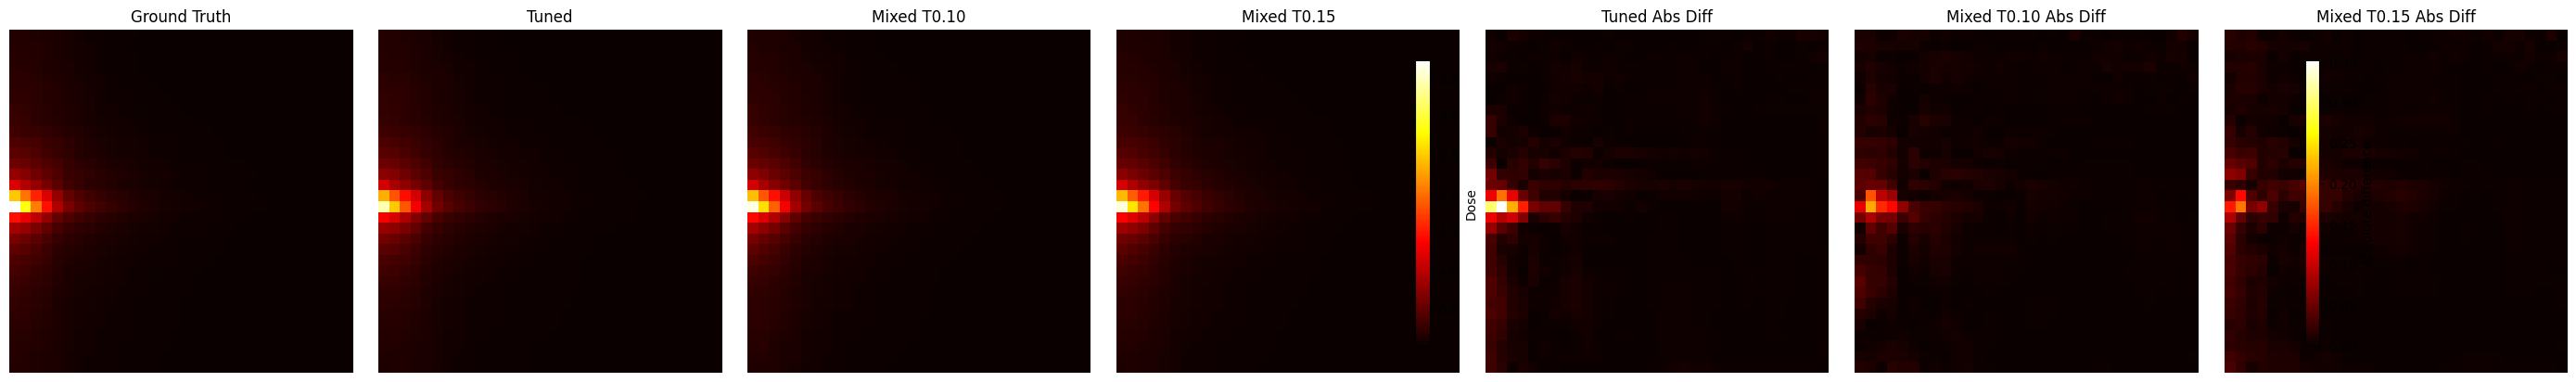

Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/ct2dose_targeted_worst_case_same_scale_all_models_evalT0p1.png


In [19]:
worst_idx = worst_case_idx

ct_vol, gt_vol, tuned_pred = get_flow_prediction(models["tuned"], val_dataset_3d, worst_idx, device, n_steps=30)
_, _, mixed010_pred = get_flow_prediction(models["mixed_T010_a030_mw3"], val_dataset_3d, worst_idx, device, n_steps=30)
_, _, mixed015_pred = get_flow_prediction(models["mixed_T015_a030_mw3"], val_dataset_3d, worst_idx, device, n_steps=30)

slice_idx = find_best_dose_slice_index(gt_vol)

gt_slice = gt_vol[slice_idx]
tuned_slice = tuned_pred[slice_idx]
mixed010_slice = mixed010_pred[slice_idx]
mixed015_slice = mixed015_pred[slice_idx]

tuned_abs_diff = np.abs(tuned_slice - gt_slice)
mixed010_abs_diff = np.abs(mixed010_slice - gt_slice)
mixed015_abs_diff = np.abs(mixed015_slice - gt_slice)

shared_vmin = 0.0
shared_vmax = max(
    float(tuned_abs_diff.max()),
    float(mixed010_abs_diff.max()),
    float(mixed015_abs_diff.max())
)

fig, axes = plt.subplots(1, 7, figsize=(28, 4))

gt_vmin = float(gt_slice.min())
gt_vmax = float(gt_slice.max())

im0 = axes[0].imshow(gt_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
axes[0].set_title("Ground Truth")
axes[0].axis("off")

im1 = axes[1].imshow(tuned_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
axes[1].set_title("Tuned")
axes[1].axis("off")

im2 = axes[2].imshow(mixed010_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
axes[2].set_title("Mixed T0.10")
axes[2].axis("off")

im3 = axes[3].imshow(mixed015_slice, cmap="hot", vmin=gt_vmin, vmax=gt_vmax)
axes[3].set_title("Mixed T0.15")
axes[3].axis("off")

im4 = axes[4].imshow(tuned_abs_diff, cmap="hot", vmin=shared_vmin, vmax=shared_vmax)
axes[4].set_title("Tuned Abs Diff")
axes[4].axis("off")

im5 = axes[5].imshow(mixed010_abs_diff, cmap="hot", vmin=shared_vmin, vmax=shared_vmax)
axes[5].set_title("Mixed T0.10 Abs Diff")
axes[5].axis("off")

im6 = axes[6].imshow(mixed015_abs_diff, cmap="hot", vmin=shared_vmin, vmax=shared_vmax)
axes[6].set_title("Mixed T0.15 Abs Diff")
axes[6].axis("off")

cbar1 = fig.colorbar(im3, ax=axes[:4], fraction=0.02, pad=0.01)
cbar1.set_label("Dose")
cbar2 = fig.colorbar(im6, ax=axes[4:], fraction=0.02, pad=0.01)
cbar2.set_label("Absolute difference")

plt.tight_layout()

same_scale_path = OUT_DIR / f"ct2dose_targeted_worst_case_same_scale_all_models_evalT{str(EVAL_THRESHOLD).replace('.', 'p')}.png"
plt.savefig(same_scale_path, dpi=150, bbox_inches="tight")
plt.show()

print("Saved:", same_scale_path)

### Step 20 — Trello Card 2 summary table

In [20]:
card2_table = summary_df[
    [
        "model",
        "overall_mae",
        "weighted_mse",
        "high_mae",
        "outside_mae",
        "outside_max_abs_error",
        "peak_core_mae",
        "peak_shoulder_mae",
    ]
].copy()

card2_table["model"] = pd.Categorical(
    card2_table["model"],
    categories=["tuned", "mixed_T010_a030_mw3", "mixed_T015_a030_mw3"],
    ordered=True
)
card2_table = card2_table.sort_values("model").reset_index(drop=True)

card2_table_fmt = card2_table.copy()
for col in card2_table_fmt.columns:
    if col != "model":
        card2_table_fmt[col] = card2_table_fmt[col].map(lambda x: f"{x:.6f}")

display(card2_table_fmt)

card2_csv = OUT_DIR / f"ct2dose_targeted_card2_summary_evalT{str(EVAL_THRESHOLD).replace('.', 'p')}.csv"
card2_table_fmt.to_csv(card2_csv, index=False)

print("Saved:", card2_csv)
print(card2_table_fmt.to_markdown(index=False))

,model,overall_mae,weighted_mse,high_mae,outside_mae,outside_max_abs_error,peak_core_mae,peak_shoulder_mae
0,tuned,0.002662,0.000038,0.004830,0.002382,0.032495,0.047654,0.022622
1,mixed_T010_a030_mw3,0.002735,0.000036,0.004753,0.002484,0.034395,0.050831,0.020989
2,mixed_T015_a030_mw3,0.002737,0.000036,0.004922,0.002441,0.035028,0.047260,0.019714


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/ct2dose_targeted_card2_summary_evalT0p1.csv
| model               |   overall_mae |   weighted_mse |   high_mae |   outside_mae |   outside_max_abs_error |   peak_core_mae |   peak_shoulder_mae |
|:--------------------|--------------:|---------------:|-----------:|--------------:|------------------------:|----------------:|--------------------:|
| tuned               |      0.002662 |        3.8e-05 |   0.00483  |      0.002382 |                0.032495 |        0.047654 |            0.022622 |
| mixed_T010_a030_mw3 |      0.002735 |        3.6e-05 |   0.004753 |      0.002484 |                0.034395 |        0.050831 |            0.020989 |
| mixed_T015_a030_mw3 |      0.002737 |        3.6e-05 |   0.004922 |      0.002441 |                0.035028 |        0.04726  |            0.019714 |


### Step 21 — Trello Card 3 representative-case table

In [21]:
card3_table = delta_vs_tuned_df.copy()

for col in card3_table.columns:
    if col not in ["case_tag", "comparison_model", "sample_idx"]:
        card3_table[col] = card3_table[col].map(lambda x: f"{x:.6f}")

display(card3_table)

card3_csv = OUT_DIR / f"ct2dose_targeted_card3_delta_evalT{str(EVAL_THRESHOLD).replace('.', 'p')}.csv"
card3_table.to_csv(card3_csv, index=False)

print("Saved:", card3_csv)

,case_tag,comparison_model,sample_idx,tuned_mse,mixed_mse,delta_mse,tuned_mae,mixed_mae,delta_mae,tuned_rel_err_pct,mixed_rel_err_pct,delta_rel_err_pct,tuned_along_mean_pct,mixed_along_mean_pct,delta_along_mean_pct,tuned_perp_mean_pct,mixed_perp_mean_pct,delta_perp_mean_pct
0,best,mixed_T010_a030_mw3,496,0.000004,0.000008,0.000004,0.001551,0.001963,0.000412,3.392290,4.293469,0.901179,3.660991,6.607055,2.946064,1.495709,3.847758,2.352049
1,best,mixed_T015_a030_mw3,496,0.000004,0.000008,0.000004,0.001551,0.002205,0.000654,3.392290,4.822049,1.429758,3.660991,5.150381,1.489390,1.495709,2.647939,1.152230
2,typical,mixed_T010_a030_mw3,491,0.000012,0.000011,-0.000002,0.002507,0.002351,-0.000157,5.396166,5.059309,-0.336857,5.287613,3.828342,-1.459271,4.050796,3.105080,-0.945717
3,typical,mixed_T015_a030_mw3,491,0.000012,0.000012,0.000000,0.002507,0.002492,-0.000015,5.396166,5.363949,-0.032217,5.287613,3.667977,-1.619637,4.050796,2.039074,-2.011722
4,worst,mixed_T010_a030_mw3,221,0.000054,0.000045,-0.000009,0.003337,0.003578,0.000241,7.069259,7.580078,0.510819,5.511676,6.630299,1.118623,8.002837,5.144266,-2.858572
5,worst,mixed_T015_a030_mw3,221,0.000054,0.000055,0.000001,0.003337,0.004175,0.000838,7.069259,8.843770,1.774511,5.511676,7.549877,2.038201,8.002837,8.361738,0.358901


Saved: /content/drive/MyDrive/rectified_flow_ct2dose/analysis/ct2dose_phase4_targeted_evaluation/ct2dose_targeted_card3_delta_evalT0p1.csv
